# X-MACE Transfer Learning Mini Tutorial

This follows the same direct-library style as the minimum example. First train a small `AutoencoderExcitedMACE` model on ethene. Then treat propene as a mock future CASPT2 pool: 500 total geometries, 50 selected expensive labels, and 450 completely unseen test geometries. Two transfer strategies are compared: naive full fine-tuning and frozen-GNN fine-tuning.


In [1]:
from pathlib import Path
import os
import copy
import json
import time

ROOT_PATH = Path.cwd()
if not (ROOT_PATH / "xyz_files").exists():
    ROOT_PATH = ROOT_PATH / "Notebooks" / "transfer_learning"

XYZ_DIR = ROOT_PATH / "xyz_files"
ETHENE_XYZ = XYZ_DIR / "A01_ethene_grid_static.xyz"
PROPENE_XYZ = XYZ_DIR / "A02_propene_grid_static.xyz"
RUN_DIR = ROOT_PATH / "transfer_learning_output"
RUN_DIR.mkdir(exist_ok=True)

# Keeps matplotlib/e3nn cache files inside this tutorial folder.
MPLCONFIGDIR = RUN_DIR / "matplotlib_cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import numpy as np
import ase.io
import torch
from e3nn import o3

from mace import data, modules, tools
from mace.tools import torch_geometric

DEVICE = torch.device("cpu")
SEED = 123
np.random.seed(SEED)
torch.manual_seed(SEED)

print("ROOT_PATH:", ROOT_PATH)
print("ETHENE_XYZ:", ETHENE_XYZ)
print("PROPENE_XYZ:", PROPENE_XYZ)
print("RUN_DIR:", RUN_DIR)
print("DEVICE:", DEVICE)

ROOT_PATH: /Users/naythanyeo/Documents/Research/2026/MLIP/Notebooks/transfer_learning
ETHENE_XYZ: /Users/naythanyeo/Documents/Research/2026/MLIP/Notebooks/transfer_learning/xyz_files/A01_ethene_grid_static.xyz
PROPENE_XYZ: /Users/naythanyeo/Documents/Research/2026/MLIP/Notebooks/transfer_learning/xyz_files/A02_propene_grid_static.xyz
RUN_DIR: /Users/naythanyeo/Documents/Research/2026/MLIP/Notebooks/transfer_learning/transfer_learning_output
DEVICE: cpu


## 1. Original Training On Ethene

This is the source model. Keep it small first so the notebook stays quick to run.

In [2]:
ETHENE_N_GEOMETRIES = 500 # Out of the total possible 3731
R_MAX = 5.0
BATCH_SIZE = 4
VALID_FRACTION = 0.2 # 20% out of the 200 geometries is used for validation
ORIGINAL_MAX_EPOCHS = 50 # Can check for when convergence happens

ethene_atoms = ase.io.read(ETHENE_XYZ, index=f":{ETHENE_N_GEOMETRIES}")
example_ethene = ethene_atoms[0]
# Max energies here is 3 because the dataset only gives 3 energies
N_ENERGIES = np.asarray(example_ethene.info["REF_energy"]).shape[-1]

print("Ethene geometries:", len(ethene_atoms))
print("Formula:", example_ethene.get_chemical_formula())
print("Energy shape:", np.asarray(example_ethene.info["REF_energy"]).shape)
print("Forces shape:", np.asarray(example_ethene.info["REF_forces"]).shape)
print("N_ENERGIES:", N_ENERGIES)

Ethene geometries: 500
Formula: C2H4
Energy shape: (1, 3)
Forces shape: (6, 3, 3)
N_ENERGIES: 3


In [3]:
# Convert ASE objects into MACE Configuration objects.
ethene_configs = data.config_from_atoms_list(
    ethene_atoms,
    energy_key="REF_energy",
    forces_key="REF_forces",
    config_type_weights={"Default": 1.0},
)

ethene_train_configs, ethene_valid_configs = data.random_train_valid_split(
    ethene_configs,
    valid_fraction=VALID_FRACTION,
    seed=SEED,
    work_dir=str(RUN_DIR),
)

print("Ethene train geometries:", len(ethene_train_configs))
print("Ethene valid geometries:", len(ethene_valid_configs))

Ethene train geometries: 400
Ethene valid geometries: 100


In [4]:
# z_table maps atomic numbers into the one-hot element vectors used by MACE.
z_table = tools.get_atomic_number_table_from_zs(
    z for config in ethene_configs for z in config.atomic_numbers
)

atomic_energies_dict = data.compute_average_E0s(ethene_train_configs, z_table)
atomic_energies = np.array([atomic_energies_dict[z] for z in z_table.zs], dtype=np.float64)

# Here we have energies for both H (1) and C (6)
print("Atomic numbers:", [int(z) for z in z_table.zs])
print("Estimated E0s:", {int(k): float(v) for k, v in atomic_energies_dict.items()})

Atomic numbers: [1, 6]
Estimated E0s: {1: -423.25118085753627, 6: -211.62559042876777}


In [5]:
# Convert Configuration objects into graph data objects.
ethene_train_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in ethene_train_configs
]
ethene_valid_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in ethene_valid_configs
]

ethene_train_loader = torch_geometric.dataloader.DataLoader(
    ethene_train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)
ethene_valid_loader = torch_geometric.dataloader.DataLoader(
    ethene_valid_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

avg_num_neighbors = modules.compute_avg_num_neighbors(ethene_train_loader)
print("Average neighbors:", float(avg_num_neighbors))

Average neighbors: 5.0


In [6]:
# Build the original ethene model directly.
# Defaults are shown beside the parameters that were intentionally made smaller.
model = modules.AutoencoderExcitedMACE(
    r_max=R_MAX,  # default = 5.0
    num_bessel=4,  # default = 8
    num_polynomial_cutoff=3,  # default = 5
    num_permutational_invariant=4,  # default = 16; latent invariant dimension
    n_energies=N_ENERGIES,  # number of electronic states in REF_energy; here this is 3
    max_ell=2,  # default = 3; spherical harmonics l value
    interaction_cls=modules.interaction_classes["RealAgnosticResidualInteractionBlock"],
    interaction_cls_first=modules.interaction_classes["RealAgnosticResidualInteractionBlock"],
    num_interactions=1,  # default = 2; message-passing layers/iterations
    num_elements=len(z_table),
    hidden_irreps=o3.Irreps("4x0e + 4x1o"),  # default = None
    MLP_irreps=o3.Irreps("4x0e"),  # default = "16x0e"
    atomic_energies=atomic_energies,
    avg_num_neighbors=float(avg_num_neighbors),
    atomic_numbers=[int(z) for z in z_table.zs],
    correlation=1,  # default = 3
    gate=modules.gate_dict["silu"],
    radial_MLP=[32, 32],  # default = [64, 64, 64]
    compute_nacs=False,  # default = False
    compute_socs=False,  # default = False
    nac_num=0,  # default = None
    soc_num=0,  # default = None
).to(DEVICE)

print(model.__class__.__name__)
print("Total parameters:", tools.count_parameters(model))


AutoencoderExcitedMACE
Total parameters: 54269


/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/opt/miniconda3/envs/mlip/lib/python3.13/ast.py:428: UserWarning: The TorchScript typ

In [7]:
loss_fn = modules.InvariantsWeightedEnergyForcesNacsDipoleLoss(
    energy_weight=1.0,
    forces_weight=5.0,
    dipoles_weight=0.0,
    nacs_weight=0.0,
    socs_weight=0.0,
)

optimizer = torch.optim.Adam(model.parameters(), lr=1.0e-3)
print("Loss function:", loss_fn)

Loss function: InvariantsWeightedEnergyForcesNacsDipoleLoss(energy_weight=1.000, forces_weight=5.000, dipole_weight=0.000)


In [8]:
"""
AutoencoderExcitedMACE needs extra tensors before calling the invariant loss.
This is the same idea as the minimum example, with active_model passed in so the
same function works for both the ethene model and the propene transfer model.
"""
def add_autoencoder_targets(active_model, batch, output):
    centred_reference_energy = (
        batch["energy"] - output["e0s"] - output["pair_energy"]
    ).unsqueeze(-1)

    output["encoded_energy"] = active_model.perm_encoder(centred_reference_energy)
    output["decoded_energy"] = (
        active_model.perm_decoder(output["encoded_energy"])
        + output["e0s"]
        + output["pair_energy"]
    )
    return output


In [9]:
original_history = []

for epoch in range(ORIGINAL_MAX_EPOCHS):
    epoch_start = time.time()
    model.train()
    train_losses = []

    for batch in ethene_train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        output = model(
            batch.to_dict(),
            training=True,
            compute_force=True,
            compute_virials=False,
            compute_stress=False,
        )

        output = add_autoencoder_targets(model, batch, output)

        # Adding the additional loss features for the encoder 
        loss = loss_fn(ref=batch, pred=output)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        train_losses.append(float(loss.detach().cpu()))

    # Put the model in evaluation mode
    # Evaluate on the validation set 
    model.eval()
    valid_losses = []
    for batch in ethene_valid_loader:
        batch = batch.to(DEVICE)
        output = model(
            batch.to_dict(),
            training=False,
            compute_force=True,
            compute_virials=False,
            compute_stress=False,
        )

        output = add_autoencoder_targets(model, batch, output)

        loss = loss_fn(ref=batch, pred=output)
        valid_losses.append(float(loss.detach().cpu()))

    row = {
        "stage": "ethene_original",
        "epoch": epoch + 1,
        "train_loss": float(np.mean(train_losses)),
        "valid_loss": float(np.mean(valid_losses)),
        "seconds": round(time.time() - epoch_start, 2),
    }
    original_history.append(row)
    print(row)

{'stage': 'ethene_original', 'epoch': 1, 'train_loss': 152.05345058441162, 'valid_loss': 181.69804088592528, 'seconds': 2.0}
{'stage': 'ethene_original', 'epoch': 2, 'train_loss': 91.16334295272827, 'valid_loss': 53.454369659423826, 'seconds': 1.53}
{'stage': 'ethene_original', 'epoch': 3, 'train_loss': 33.74040725708008, 'valid_loss': 28.052830848693848, 'seconds': 1.57}
{'stage': 'ethene_original', 'epoch': 4, 'train_loss': 25.64573740005493, 'valid_loss': 20.973307342529296, 'seconds': 1.54}
{'stage': 'ethene_original', 'epoch': 5, 'train_loss': 22.048030252456666, 'valid_loss': 24.704922485351563, 'seconds': 1.52}
{'stage': 'ethene_original', 'epoch': 6, 'train_loss': 22.119249048233034, 'valid_loss': 19.479563217163086, 'seconds': 1.51}
{'stage': 'ethene_original', 'epoch': 7, 'train_loss': 23.962247467041017, 'valid_loss': 21.93010139465332, 'seconds': 1.54}
{'stage': 'ethene_original', 'epoch': 8, 'train_loss': 21.10542424201965, 'valid_loss': 22.774971694946288, 'seconds': 1.5}

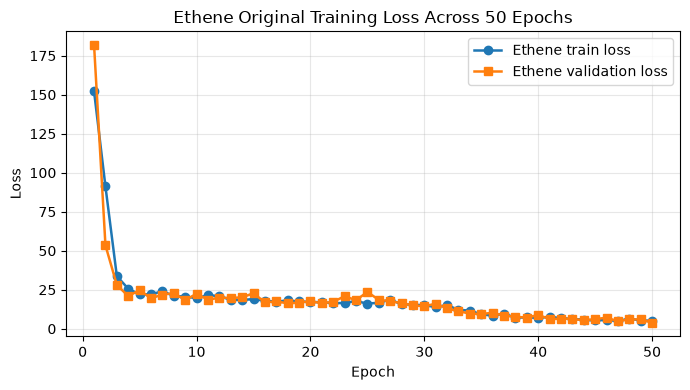

Saved loss curve: /Users/naythanyeo/Documents/Research/2026/MLIP/Notebooks/transfer_learning/transfer_learning_output/ethene_original_loss_curve.png


In [10]:
import matplotlib.pyplot as plt

# original_history is written by the ethene training loop above.
epochs = [row["epoch"] for row in original_history]
train_losses = [row["train_loss"] for row in original_history]
valid_losses = [row["valid_loss"] for row in original_history]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, train_losses, marker="o", linewidth=1.8, label="Ethene train loss")
ax.plot(epochs, valid_losses, marker="s", linewidth=1.8, label="Ethene validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"Ethene Original Training Loss Across {ORIGINAL_MAX_EPOCHS} Epochs")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

LOSS_PLOT_PATH = RUN_DIR / "ethene_original_loss_curve.png"
fig.savefig(LOSS_PLOT_PATH, dpi=150)
plt.show()

print("Saved loss curve:", LOSS_PLOT_PATH)


In [11]:
"""
With 50 epochs from above, it looks like it might be still underfitting slightly 
Can try to train with more data or for longer? 
Below is the important save path to save the model to use for transfer learning
"""
ORIGINAL_STATE_PATH = RUN_DIR / "ethene_original_state.pt"
torch.save(model.state_dict(), ORIGINAL_STATE_PATH)
print("Saved original model state:", ORIGINAL_STATE_PATH)

Saved original model state: /Users/naythanyeo/Documents/Research/2026/MLIP/Notebooks/transfer_learning/transfer_learning_output/ethene_original_state.pt


## 2. Propene Transfer Learning Data Selection

Imagine the first 500 propene geometries as the mock full CASPT2 expensive dataset. We sort this full pool by a simple C-C-C angle metric, then take every 10th geometry from the sorted list. This gives 50 selected geometries that span the angle range.

Those 50 selected geometries become `propene_configs`, which are then split into train/validation using MACE's `random_train_valid_split`. The remaining 450 geometries are kept as unseen test data.


In [12]:
PROPENE_POOL_SIZE = 500
PROPENE_LABELLED_COUNT = 50
PROPENE_VALID_FRACTION = 0.20

propene_atoms_pool = ase.io.read(PROPENE_XYZ, index=f":{PROPENE_POOL_SIZE}")

# Function that takes an atom object, output the angle
# In this case it measures the C-C-C angle, so it checks where the C indexes are only
def get_angle(atom):
    symbols = atom.get_chemical_symbols()
    carbon_indices = [idx for idx, symbol in enumerate(symbols) if symbol == "C"]
    # This function works for PROPENE with 3 carbons only, the angle is defined 
    # to be between those 3 Cs only. Other molecules maybe use rdkit for descriptors
    # is better. RDkit is probably cleaner
    angle_i, angle_j, angle_k = carbon_indices
    positions = atom.get_positions()
    # Meth gg vectors
    vector_ji = positions[angle_i] - positions[angle_j]
    vector_jk = positions[angle_k] - positions[angle_j]
    cosine_angle = np.dot(vector_ji, vector_jk) / (
        np.linalg.norm(vector_ji) * np.linalg.norm(vector_jk)
    )
    # Principle angle
    angle_degrees = np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))

    return angle_degrees

propene_angles = [get_angle(atom) for atom in propene_atoms_pool]
propene_angles = np.array(propene_angles) # Convert list to numpy array

print("Propene pool:", len(propene_atoms_pool))
print("Formula:", propene_atoms_pool[0].get_chemical_formula())
print("C-C-C angle range, degrees:", float(propene_angles.min()), "to", float(propene_angles.max()))
print("C-C-C angle mean/std:", float(propene_angles.mean()), float(propene_angles.std()))

Propene pool: 500
Formula: C3H6
C-C-C angle range, degrees: 26.467862022031145 to 32.394130875221556
C-C-C angle mean/std: 29.111303319006456 1.746191756068137


In [13]:
PROPENE_SELECTION_STRIDE = 10

# Sort the full propene pool (500 geometries) based on their angles 
propene_sorted_records = sorted(
    enumerate(propene_atoms_pool),
    key=lambda item: propene_angles[item[0]],
)
"""
Pick every 10th geometry from the angle-sorted pool: 500 / 10 = 50 geometries.
In this case this represents an evenly sorted selection (just take every 10th entry)
Can explore a lot more here to find a nice strategy that works well, instead of just
taking evenly spaced entries. 
Can code in new functions to select different angles? maybe for eg take more small 
angles vs take a lot of large angles?

End state just define propene_labelled_atoms differently. Need a function that will
take in the original propene_atoms_pool (500 entries) --> propene_labelled_atoms (50)
For this dataset probably not much difference tbh but can try 
Can explore taking different attributes also, like here use angle but maybe other things
like bond length can be coded in? 
"""
# Extract the original pool indices in angle-sorted order.
propene_sorted_indices = np.array([idx for idx, atoms in propene_sorted_records])

# Pick every 10th original index after sorting by angle.
propene_labelled_indices = propene_sorted_indices[::PROPENE_SELECTION_STRIDE]
propene_labelled_atoms = [propene_atoms_pool[idx] for idx in propene_labelled_indices]

# This is the selected labelled transfer dataset.
# Use back the mace data class same steps as before 
propene_configs = data.config_from_atoms_list(
    propene_labelled_atoms,
    energy_key="REF_energy",
    forces_key="REF_forces",
    config_type_weights={"Default": 1.0},
)

# Everything not selected is treated as fully unseen test data.
selected_index_set = set(propene_labelled_indices.tolist())
# If it is not a selected index, it is a test index
propene_test_indices = np.array([
    idx for idx in range(len(propene_atoms_pool))
    if idx not in selected_index_set
])
# Test atoms (this is the 450 unseen geometries)
propene_test_atoms = [propene_atoms_pool[idx] for idx in propene_test_indices]
propene_test_configs = data.config_from_atoms_list(
    propene_test_atoms,
    energy_key="REF_energy",
    forces_key="REF_forces",
    config_type_weights={"Default": 1.0},
)

print("Selected labelled geometries:", len(propene_configs))
print("Unseen test geometries:", len(propene_test_configs))


Selected labelled geometries: 50
Unseen test geometries: 450


In [14]:
# Split only the 50 selected labelled configurations into train/validation.
# Just like before no change
propene_train_configs, propene_valid_configs = data.random_train_valid_split(
    propene_configs,
    valid_fraction=PROPENE_VALID_FRACTION,
    seed=SEED,
    work_dir=str(RUN_DIR),
)

In [15]:
"""
In this case, we can use the same z_table from ethene because both only contain C and H
Quite conveninet lol
But if got other molecule with more atoms then need to redefine to get the 
"initial starting guess" for the model

Below now we have train validation and test set. The "test" set is abit more rigorous
way of checking the resutls cause it doesnt see it at all. The test set is the 450 other
geometries we didnt use before. We only use it at the end, but prepare it now.
"""
propene_train_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in propene_train_configs
]
propene_valid_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in propene_valid_configs
]
propene_test_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in propene_test_configs
]

propene_train_loader = torch_geometric.dataloader.DataLoader(
    propene_train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)
propene_valid_loader = torch_geometric.dataloader.DataLoader(
    propene_valid_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)
propene_test_loader = torch_geometric.dataloader.DataLoader(
    propene_test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

In [16]:
"""
This is the important part for TL, we use the model defined before 
This object "model" is the same model defined for ethene (same parameters etc)
For a simple transfer learning just freezing layers etc, we can simply make a copy
Basically duplicate the model, give it the new dataset then let it learn again 
So our propene_base_model is a copy of it, it inherits all the original attributes
of the original class. We can edit it slightly later on here
"""
propene_base_model = copy.deepcopy(model).to(DEVICE)
propene_base_model.eval()

print("Base model class:", propene_base_model.__class__.__name__)
print("Base model parameters:", tools.count_parameters(propene_base_model))

Base model class: AutoencoderExcitedMACE
Base model parameters: 54269


## 3. Strategy 1: Naive Transfer Learning

Here the first transfer learning strategy we try is to naively transfer, meaning just use the initial paramters learned from ethene, and then retrain on propene. So we basically don't change anything, just start from the initial set of weights. 

In [17]:
TRANSFER_MAX_EPOCHS = 50
TRANSFER_LR = 5.0e-4

"""
Here we make copies of all the train_loader and models so that it remains independent
of the other strategies. Can test Strategy 2 without this affecting it. 
"""
naive_train_set = copy.deepcopy(propene_train_set)
naive_valid_set = copy.deepcopy(propene_valid_set)
naive_test_set = copy.deepcopy(propene_test_set)

naive_train_loader = torch_geometric.dataloader.DataLoader(
    naive_train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)
naive_valid_loader = torch_geometric.dataloader.DataLoader(
    naive_valid_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)
naive_test_loader = torch_geometric.dataloader.DataLoader(
    naive_test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

naive_model = copy.deepcopy(propene_base_model).to(DEVICE)

naive_optimizer = torch.optim.Adam(naive_model.parameters(), lr=TRANSFER_LR)
naive_trainable_count = sum(param.numel() for param in naive_model.parameters() if param.requires_grad)

print("Naive model parameters:", tools.count_parameters(naive_model))
print("Naive trainable parameters:", naive_trainable_count)

"""
Here trainable_count counts the total number of paramters that require grad
By default, all layers and stages in the model have require_grad True, meaning that
the weights will be re optimised. 
In this naive example, none of the weights are frozen, so all the parameters are going
to be re trained with the new data. 
"""


Naive model parameters: 54269
Naive trainable parameters: 54269


'\nHere trainable_count counts the total number of paramters that require grad\nBy default, all layers and stages in the model have require_grad True, meaning that\nthe weights will be re optimised. \nIn this naive example, none of the weights are frozen, so all the parameters are going\nto be re trained with the new data. \n'

In [18]:
# Same training methods as before
naive_history = []
for epoch in range(TRANSFER_MAX_EPOCHS):
    epoch_start = time.time()
    naive_model.train()
    train_losses = []

    for batch in naive_train_loader:
        batch = batch.to(DEVICE)
        naive_optimizer.zero_grad(set_to_none=True)

        output = naive_model(
            batch.to_dict(),
            training=True,
            compute_force=True,
            compute_virials=False,
            compute_stress=False,
        )
        output = add_autoencoder_targets(naive_model, batch, output)

        loss = loss_fn(ref=batch, pred=output)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(naive_model.parameters(), max_norm=10.0)
        naive_optimizer.step()
        train_losses.append(float(loss.detach().cpu()))

    naive_model.eval()
    valid_losses = []
    for batch in naive_valid_loader:
        batch = batch.to(DEVICE)
        output = naive_model(
            batch.to_dict(),
            training=False,
            compute_force=True,
            compute_virials=False,
            compute_stress=False,
        )
        output = add_autoencoder_targets(naive_model, batch, output)

        loss = loss_fn(ref=batch, pred=output)
        valid_losses.append(float(loss.detach().cpu()))

    row = {
        "stage": "propene_naive_transfer",
        "epoch": epoch + 1,
        "train_loss": float(np.mean(train_losses)),
        "valid_loss": float(np.mean(valid_losses)),
        "seconds": round(time.time() - epoch_start, 2),
    }
    naive_history.append(row)
    print(row)


{'stage': 'propene_naive_transfer', 'epoch': 1, 'train_loss': 335.3357391357422, 'valid_loss': 126.93350474039714, 'seconds': 0.19}
{'stage': 'propene_naive_transfer', 'epoch': 2, 'train_loss': 125.17029304504395, 'valid_loss': 54.02625401814779, 'seconds': 0.17}
{'stage': 'propene_naive_transfer', 'epoch': 3, 'train_loss': 75.9410228729248, 'valid_loss': 35.79760615030924, 'seconds': 0.16}
{'stage': 'propene_naive_transfer', 'epoch': 4, 'train_loss': 58.3184139251709, 'valid_loss': 33.69009971618652, 'seconds': 0.16}
{'stage': 'propene_naive_transfer', 'epoch': 5, 'train_loss': 51.94612903594971, 'valid_loss': 29.484839121500652, 'seconds': 0.17}
{'stage': 'propene_naive_transfer', 'epoch': 6, 'train_loss': 47.952017593383786, 'valid_loss': 27.647289276123047, 'seconds': 0.16}
{'stage': 'propene_naive_transfer', 'epoch': 7, 'train_loss': 44.212667083740236, 'valid_loss': 25.929755846659344, 'seconds': 0.16}
{'stage': 'propene_naive_transfer', 'epoch': 8, 'train_loss': 42.5223987579345

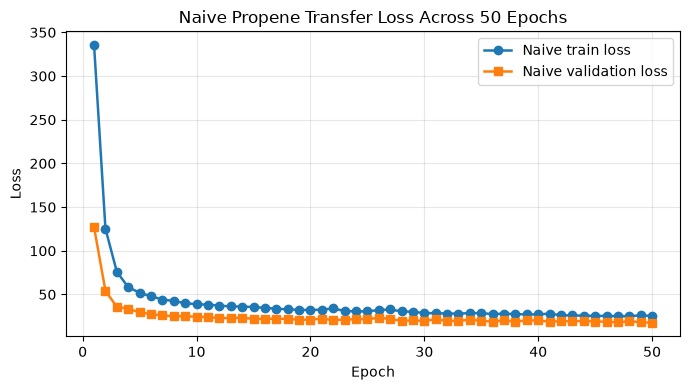

In [19]:
import matplotlib.pyplot as plt

# Plot train vs validation loss for the naive transfer-learning run.
naive_epochs = [row["epoch"] for row in naive_history]
naive_train_losses = [row["train_loss"] for row in naive_history]
naive_valid_losses = [row["valid_loss"] for row in naive_history]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(naive_epochs, naive_train_losses, marker="o", linewidth=1.8, label="Naive train loss")
ax.plot(naive_epochs, naive_valid_losses, marker="s", linewidth=1.8, label="Naive validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"Naive Propene Transfer Loss Across {TRANSFER_MAX_EPOCHS} Epochs")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

NAIVE_LOSS_PLOT_PATH = RUN_DIR / "propene_naive_transfer_loss_curve.png"
fig.savefig(NAIVE_LOSS_PLOT_PATH, dpi=150)
plt.show()


In [20]:
# Final evaluation: average loss on the unseen propene test set only.
naive_model.eval()
naive_test_losses_after = []

for batch in naive_test_loader:
    batch = batch.to(DEVICE)
    output = naive_model(
        batch.to_dict(),
        training=False,
        compute_force=True,
        compute_virials=False,
        compute_stress=False,
    )
    output = add_autoencoder_targets(naive_model, batch, output)
    loss = loss_fn(ref=batch, pred=output)
    naive_test_losses_after.append(float(loss.detach().cpu()))

test_loss = float(np.mean(naive_test_losses_after))

print("FINAL TEST LOSS: ", test_loss)


FINAL TEST LOSS:  24.513366884889855


In [21]:
NAIVE_STATE_PATH = RUN_DIR / "propene_naive_transfer_state.pt"
torch.save(naive_model.state_dict(), NAIVE_STATE_PATH)
print("Saved naive transfer model state:", NAIVE_STATE_PATH)

Saved naive transfer model state: /Users/naythanyeo/Documents/Research/2026/MLIP/Notebooks/transfer_learning/transfer_learning_output/propene_naive_transfer_state.pt


## 4. Strategy 2: Transfer Learning With Frozen GNN

This time we try out a new transfer learning strategy compare to before which we just retrained with the initial parameters. 

In [22]:
# For the new strategy create a copy of the dataset and model again
frozen_train_set = copy.deepcopy(propene_train_set)
frozen_valid_set = copy.deepcopy(propene_valid_set)
frozen_test_set = copy.deepcopy(propene_test_set)

frozen_train_loader = torch_geometric.dataloader.DataLoader(
    frozen_train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)
frozen_valid_loader = torch_geometric.dataloader.DataLoader(
    frozen_valid_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)
frozen_test_loader = torch_geometric.dataloader.DataLoader(
    frozen_test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

frozen_model = copy.deepcopy(propene_base_model).to(DEVICE)

frozen_optimizer = torch.optim.Adam(
    [param for param in frozen_model.parameters() if param.requires_grad],
    lr=TRANSFER_LR,
)



In [23]:
"""
Here we quickly inspect the models parameters. This is important because we want to
freeze certain layers of the entire neural network. The model class has many "blocks"
which are different classes of layers. Each layer does something different, and they
connect to ecah other. The stuff printed below is not the actual order of the model. 

The actual full model roughly does something like 
GRAPH NEURAL NETWORK STAGE
1. atomic_energies_fn
    - This is the baseline we got from the average energy. 
    - Basically the starting energy value that we input into the model. 
    - This is our integration constant ish (no trainable parameters)
2. node embedding  
    - This part converts atoms C H etc into vectors (embeddings)
    - Notice only got 8 trainable paramters 
    - This should form the nodes of the GNN
3. radial embeddings + spherical_harmonics 
    - This part is the equivariant shit I think? 
    - I think this is just a math mapping for your atom geometry 
    - Importantly its to ensure that if you rotate the coordinates but the relative 
      spacing between them is the same, it maps to a certain unique input 
    - Somehow with math of spherical harmonics they can do it
    - This should form the edges of the GNN 
    - Mathematical mapping --> 0 trainable parameters
4. interactions
    - This is the message passing layer of the GNN
    - The goassip stage where the nodes talk to each other to learn about each other 
    - This will learn atom level features (each atom / node has one updated vector)
    - 1632 trainable parameters
5. products
    - This should be the final layer of the GNN, after the message passing layer
    - Takes the atom level features and expands it to make it richer 
    - Similar to Feed Forward Neural Network I think but with symmetry enforced 

After this stage, all the atom vectors are collapsed into one vector. 
It is trained to learn a latent space (lower dimension vector), then decode to get energies
Basically for autoencoder you train from energies to energies, trying to get back itself.
by having an encoder and decoder. So you learn lower level features which is somehow easier.

But seriously weird here because it seems like X-MACE does this autoencoder training and the
GNN -> latent space training together. Not sure why or how they even get the gradients to 
flow, but for another time. 
"""

for name, module in frozen_model.named_children():
    total = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    print(f"{name:30s} {module.__class__.__name__:35s} total={total:,} trainable={trainable:,}")

node_embedding                 LinearNodeEmbeddingBlock            total=8 trainable=8
radial_embedding               RadialEmbeddingBlock                total=0 trainable=0
perm_encoder                   PermutationInvariantEncoder         total=1,732 trainable=1,732
perm_decoder                   PermutationInvariantDecoder         total=50,821 trainable=50,821
spherical_harmonics            SphericalHarmonics                  total=0 trainable=0
atomic_energies_fn             AtomicEnergiesBlock                 total=0 trainable=0
interactions                   ModuleList                          total=1,632 trainable=1,632
products                       ModuleList                          total=48 trainable=48
socs_readouts                  ModuleList                          total=0 trainable=0
readouts                       ModuleList                          total=12 trainable=12
invariant_readouts             ModuleList                          total=16 trainable=16


In [24]:
"""
Importantly, from the previous output, we can now know which layers to freeze in the model.
As a start, we freeze the graph/message-passing parts of the model. This means that during
training the gradients will not flow through them, so the weights are frozen and unchanged

Model has many attributes, each param below is its own class part of the model 
Update that block's class to requires_grad = False to freeze it
We just need to freeze the node embedding, interactions and products 
radial_embedding and spherical_harmonics are math maps without trainable parameters (above)
"""

gnn_prefixes = ("node_embedding", "interactions", "products")
for name, param in frozen_model.named_parameters():
    if name.startswith(gnn_prefixes):
        param.requires_grad = False


frozen_trainable_count = sum(param.numel() for param in frozen_model.parameters() if param.requires_grad)
frozen_parameter_count = tools.count_parameters(frozen_model)

print("Frozen-GNN model parameters:", frozen_parameter_count)
print("Frozen-GNN trainable parameters:", frozen_trainable_count)
print("Frozen prefixes:", gnn_prefixes)
"""
Here you can see also that we still keep most of the autoencoder parameters in training
Only freeze and keep constant the graphs (first few thousands parameters)
"""

Frozen-GNN model parameters: 54269
Frozen-GNN trainable parameters: 52581
Frozen prefixes: ('node_embedding', 'interactions', 'products')


'\nHere you can see also that we still keep most of the autoencoder parameters in training\nOnly freeze and keep constant the graphs (first few thousands parameters)\n'

In [25]:
# Try the training again, same as before
frozen_history = []

for epoch in range(TRANSFER_MAX_EPOCHS):
    epoch_start = time.time()
    frozen_model.train()
    train_losses = []

    for batch in frozen_train_loader:
        batch = batch.to(DEVICE)
        frozen_optimizer.zero_grad(set_to_none=True)

        output = frozen_model(
            batch.to_dict(),
            training=True,
            compute_force=True,
            compute_virials=False,
            compute_stress=False,
        )
        output = add_autoencoder_targets(frozen_model, batch, output)

        loss = loss_fn(ref=batch, pred=output)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(frozen_model.parameters(), max_norm=10.0)
        frozen_optimizer.step()
        train_losses.append(float(loss.detach().cpu()))

    frozen_model.eval()
    valid_losses = []
    for batch in frozen_valid_loader:
        batch = batch.to(DEVICE)
        output = frozen_model(
            batch.to_dict(),
            training=False,
            compute_force=True,
            compute_virials=False,
            compute_stress=False,
        )
        output = add_autoencoder_targets(frozen_model, batch, output)

        loss = loss_fn(ref=batch, pred=output)
        valid_losses.append(float(loss.detach().cpu()))

    row = {
        "stage": "propene_frozen_gnn_transfer",
        "epoch": epoch + 1,
        "train_loss": float(np.mean(train_losses)),
        "valid_loss": float(np.mean(valid_losses)),
        "seconds": round(time.time() - epoch_start, 2),
    }
    frozen_history.append(row)
    print(row)

{'stage': 'propene_frozen_gnn_transfer', 'epoch': 1, 'train_loss': 363.7437454223633, 'valid_loss': 141.44605000813803, 'seconds': 0.19}
{'stage': 'propene_frozen_gnn_transfer', 'epoch': 2, 'train_loss': 135.47306747436522, 'valid_loss': 57.61201731363932, 'seconds': 0.16}
{'stage': 'propene_frozen_gnn_transfer', 'epoch': 3, 'train_loss': 75.59129199981689, 'valid_loss': 37.305737813313804, 'seconds': 0.16}
{'stage': 'propene_frozen_gnn_transfer', 'epoch': 4, 'train_loss': 58.22135715484619, 'valid_loss': 32.43805122375488, 'seconds': 0.16}
{'stage': 'propene_frozen_gnn_transfer', 'epoch': 5, 'train_loss': 52.415899467468265, 'valid_loss': 29.70040003458659, 'seconds': 0.16}
{'stage': 'propene_frozen_gnn_transfer', 'epoch': 6, 'train_loss': 49.23722038269043, 'valid_loss': 28.549380620320637, 'seconds': 0.15}
{'stage': 'propene_frozen_gnn_transfer', 'epoch': 7, 'train_loss': 47.661053848266604, 'valid_loss': 27.615999221801758, 'seconds': 0.16}
{'stage': 'propene_frozen_gnn_transfer', 

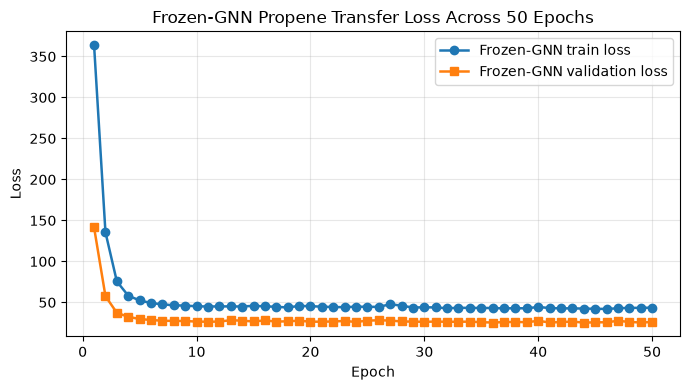

In [26]:
import matplotlib.pyplot as plt

# Plot train vs validation loss for the frozen-GNN transfer-learning run.
frozen_epochs = [row["epoch"] for row in frozen_history]
frozen_train_losses = [row["train_loss"] for row in frozen_history]
frozen_valid_losses = [row["valid_loss"] for row in frozen_history]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(frozen_epochs, frozen_train_losses, marker="o", linewidth=1.8, label="Frozen-GNN train loss")
ax.plot(frozen_epochs, frozen_valid_losses, marker="s", linewidth=1.8, label="Frozen-GNN validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"Frozen-GNN Propene Transfer Loss Across {TRANSFER_MAX_EPOCHS} Epochs")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

FROZEN_LOSS_PLOT_PATH = RUN_DIR / "propene_frozen_gnn_transfer_loss_curve.png"
fig.savefig(FROZEN_LOSS_PLOT_PATH, dpi=150)
plt.show()



In [27]:
# Final evaluation: average loss on the unseen propene test set only.
frozen_model.eval()
frozen_test_losses_after = []

for batch in frozen_test_loader:
    batch = batch.to(DEVICE)
    output = frozen_model(
        batch.to_dict(),
        training=False,
        compute_force=True,
        compute_virials=False,
        compute_stress=False,
    )
    output = add_autoencoder_targets(frozen_model, batch, output)
    loss = loss_fn(ref=batch, pred=output)
    frozen_test_losses_after.append(float(loss.detach().cpu()))

frozen_test_loss = float(np.mean(frozen_test_losses_after))
frozen_loss_after = {"test": frozen_test_loss}

print("FINAL TEST LOSS: ", frozen_test_loss)



FINAL TEST LOSS:  41.76458800155505


In [28]:
FROZEN_STATE_PATH = RUN_DIR / "propene_frozen_gnn_transfer_state.pt"
torch.save(frozen_model.state_dict(), FROZEN_STATE_PATH)
print("Saved frozen-GNN transfer model state:", FROZEN_STATE_PATH)

Saved frozen-GNN transfer model state: /Users/naythanyeo/Documents/Research/2026/MLIP/Notebooks/transfer_learning/transfer_learning_output/propene_frozen_gnn_transfer_state.pt


In [29]:
print(f"Strategy 1 Naive Transfer Test Loss: {test_loss}")
print(f"Strategy 2 Frozen GNN Test Loss: {frozen_test_loss}")

Strategy 1 Naive Transfer Test Loss: 24.513366884889855
Strategy 2 Frozen GNN Test Loss: 41.76458800155505


As seen above, the frozen GNN model seems to perform worse, with a larger test loss. 
Again this dataset is very small so results don't mean much, but intuitvely freezing the
GNN here did not make sense, because the GNN is meant to learn the molecule features. 

Generally we want to freeze layers so that the model can save time, and given a smaller dataset, it will not over fit. Eg. if you have only 10% of the original dataset, the model
can more easily "memorise" the data and over fit. If you freeze the weights, you prevent
the model from unlearning what it learned before. 

In this example, we used transfer learning from Ethene to Propene, so freezing the GNN 
likely meant some of the required chemical information was not captured properly? Again 
this is very speculative because the dataset is so small so can't really have much 
meaningful conclusions. Maybe can try using more data and testing to see what happens?

However, if next time we apply transfer learning from CASSCF->CASPT2, the molecules are the
same, just degree of accuracy is improved, so maybe GNN freezing will make more sense? 
Or freezing the autoencoder / learning the same invariant latent space? 

Can even try freezing everything except for the GNN or smth lol

Endless possibilities, can only really guess what makes sense, test out different methods
and compare the loss to see how it performs...